In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.7 MB/s eta 0:00:00


In [2]:
import pickle

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_stress = load_pickle("X_stress.pkl")
X_strain = load_pickle("X_strain.pkl")
y_stress = load_pickle("y_stress.pkl")
y_strain = load_pickle("y_strain.pkl")

'''5 values:
Q (параметр нагрузки/деформации)
k ( коэффициент калибровочного участка)
alpha (угол, геометрия)
mu (коэффициент трения)
v (скорость)
'''
print("X_stress:", type(X_stress), getattr(X_stress, "shape", None))
print("X_strain:", type(X_strain), getattr(X_strain, "shape", None))
print("y_stress:", type(y_stress), getattr(y_stress, "shape", None))
print("y_strain:", type(y_strain), getattr(y_strain, "shape", None))

print("\nExample values:")
print("X_stress[0]:", X_stress[0])
print("y_stress[0]:", y_stress[0])


X_stress: <class 'numpy.ndarray'> (4, 2028, 5)
X_strain: <class 'numpy.ndarray'> (4, 2438, 5)
y_stress: <class 'numpy.ndarray'> (4, 2028, 20)
y_strain: <class 'numpy.ndarray'> (4, 2438, 20)

Example values:
X_stress[0]: [[ 0.1    0.     8.     0.1   10.   ]
 [ 0.1    0.     8.     0.025 10.   ]
 [ 0.1    0.     8.     0.05  10.   ]
 ...
 [ 0.15   0.    20.     0.1    5.   ]
 [ 0.15   0.    20.     0.025  5.   ]
 [ 0.15   0.    20.     0.05   5.   ]]
y_stress[0]: [[-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 ...
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]]


[I 2026-05-19 18:51:47,643] A new study created in memory with name: no-name-e208c596-6609-431a-acdb-4a463c4170c0


✓ GPU detected: NVIDIA A100-SXM4-40GB  (42.4 GB VRAM)
  torch version  : 2.10.0+cu128
  cuda available : True  (cuda version: 12.8)
  → A100 detected: TF32 enabled, cudnn.benchmark=True

══════════════════════════════════════════════════════════════════════════
ОБУЧАЮЩАЯ ВЫБОРКА  (X_stress.pkl / y_stress.pkl, cleaned, Abaqus convention, МПа)
══════════════════════════════════════════════════════════════════════════
X_mlp  : (40560, 6)   [p1..p5, r]
y_mlp  : (40560, 4)   [σ_rr, σ_θθ, σ_zz, τ_rz]
Mapping: stress_33→σ_rr | stress_11→σ_θθ | stress_22→σ_zz | stress_12→τ_rz

Диапазоны y (все реальные FEM данные):
  sigma_rr  : [    -418.6,      0.1331]   mean_abs=109.6
  sigma_tt  : [      -292,       282.6]   mean_abs=62.92
  sigma_zz  : [    -299.6,       214.1]   mean_abs=58.07
  tau_rz    : [    -301.3,          25]   mean_abs=47.92

Информативно — BC проверка для FEM (r=1, последний r-индекс):
  (MLP не использует BC в loss, но FEM-данные эту BC соблюдают)
  σ_rr at r=1: mean=-5.911  ma

[I 2026-05-19 18:52:10,982] Trial 0 finished with value: 25.255030517791777 and parameters: {'n_layers': 3, 'n_units_0': 221, 'n_units_1': 251, 'n_units_2': 135, 'activation': 'tanh', 'learning_rate': 0.00014721663764177665, 'batch_size': 64, 'optimizer': 'Adam', 'max_epochs': 351, 'grad_clip': 1.4205397735392438, 'weight_decay': 0.007487840452499565}. Best is trial 0 with value: 25.255030517791777.
[I 2026-05-19 18:52:24,349] Trial 1 finished with value: 19.935368276958474 and parameters: {'n_layers': 4, 'n_units_0': 218, 'n_units_1': 167, 'n_units_2': 233, 'n_units_3': 156, 'activation': 'tanh', 'learning_rate': 0.000828682114313045, 'batch_size': 64, 'optimizer': 'Adam', 'max_epochs': 516, 'grad_clip': 1.7946053169630958, 'weight_decay': 0.0002194795576565028}. Best is trial 1 with value: 19.935368276958474.
[I 2026-05-19 18:53:16,632] Trial 2 finished with value: 19.470560037183983 and parameters: {'n_layers': 6, 'n_units_0': 119, 'n_units_1': 134, 'n_units_2': 180, 'n_units_3': 24

Best params: {'n_layers': 4, 'n_units_0': 207, 'n_units_1': 246, 'n_units_2': 238, 'n_units_3': 92, 'activation': 'tanh', 'learning_rate': 0.001763139643145048, 'batch_size': 64, 'optimizer': 'Adam', 'max_epochs': 544, 'grad_clip': 4.339321973902675, 'weight_decay': 0.000674277370823244}

★ Optuna search закончен за 579.4 с  (≈ 29.0 с / trial)
  best_inner_val (worst-fold macro RMSE): 18.8776
  best_params:
    n_layers           = 4
    n_units_0          = 207
    n_units_1          = 246
    n_units_2          = 238
    n_units_3          = 92
    activation         = tanh
    learning_rate      = 0.00176314
    batch_size         = 64
    optimizer          = Adam
    max_epochs         = 544
    grad_clip          = 4.33932
    weight_decay       = 0.000674277

══════════════════════════════════════════════════════════════════════════
5-FOLD КРОСС-ВАЛИДАЦИЯ С ЛУЧШИМИ ГИПЕРПАРАМЕТРАМИ  (на TRAINVAL)
══════════════════════════════════════════════════════════════════════════
Using de

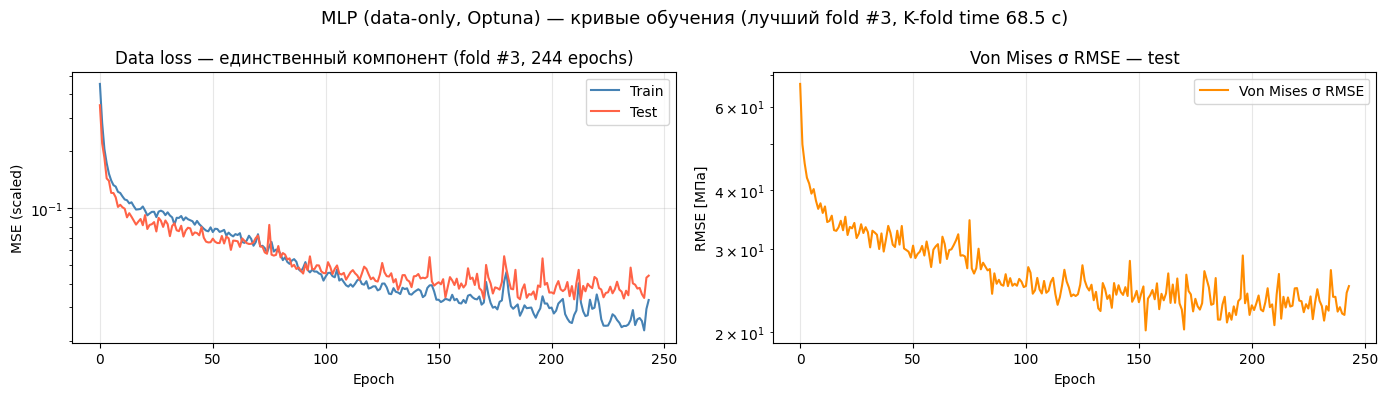

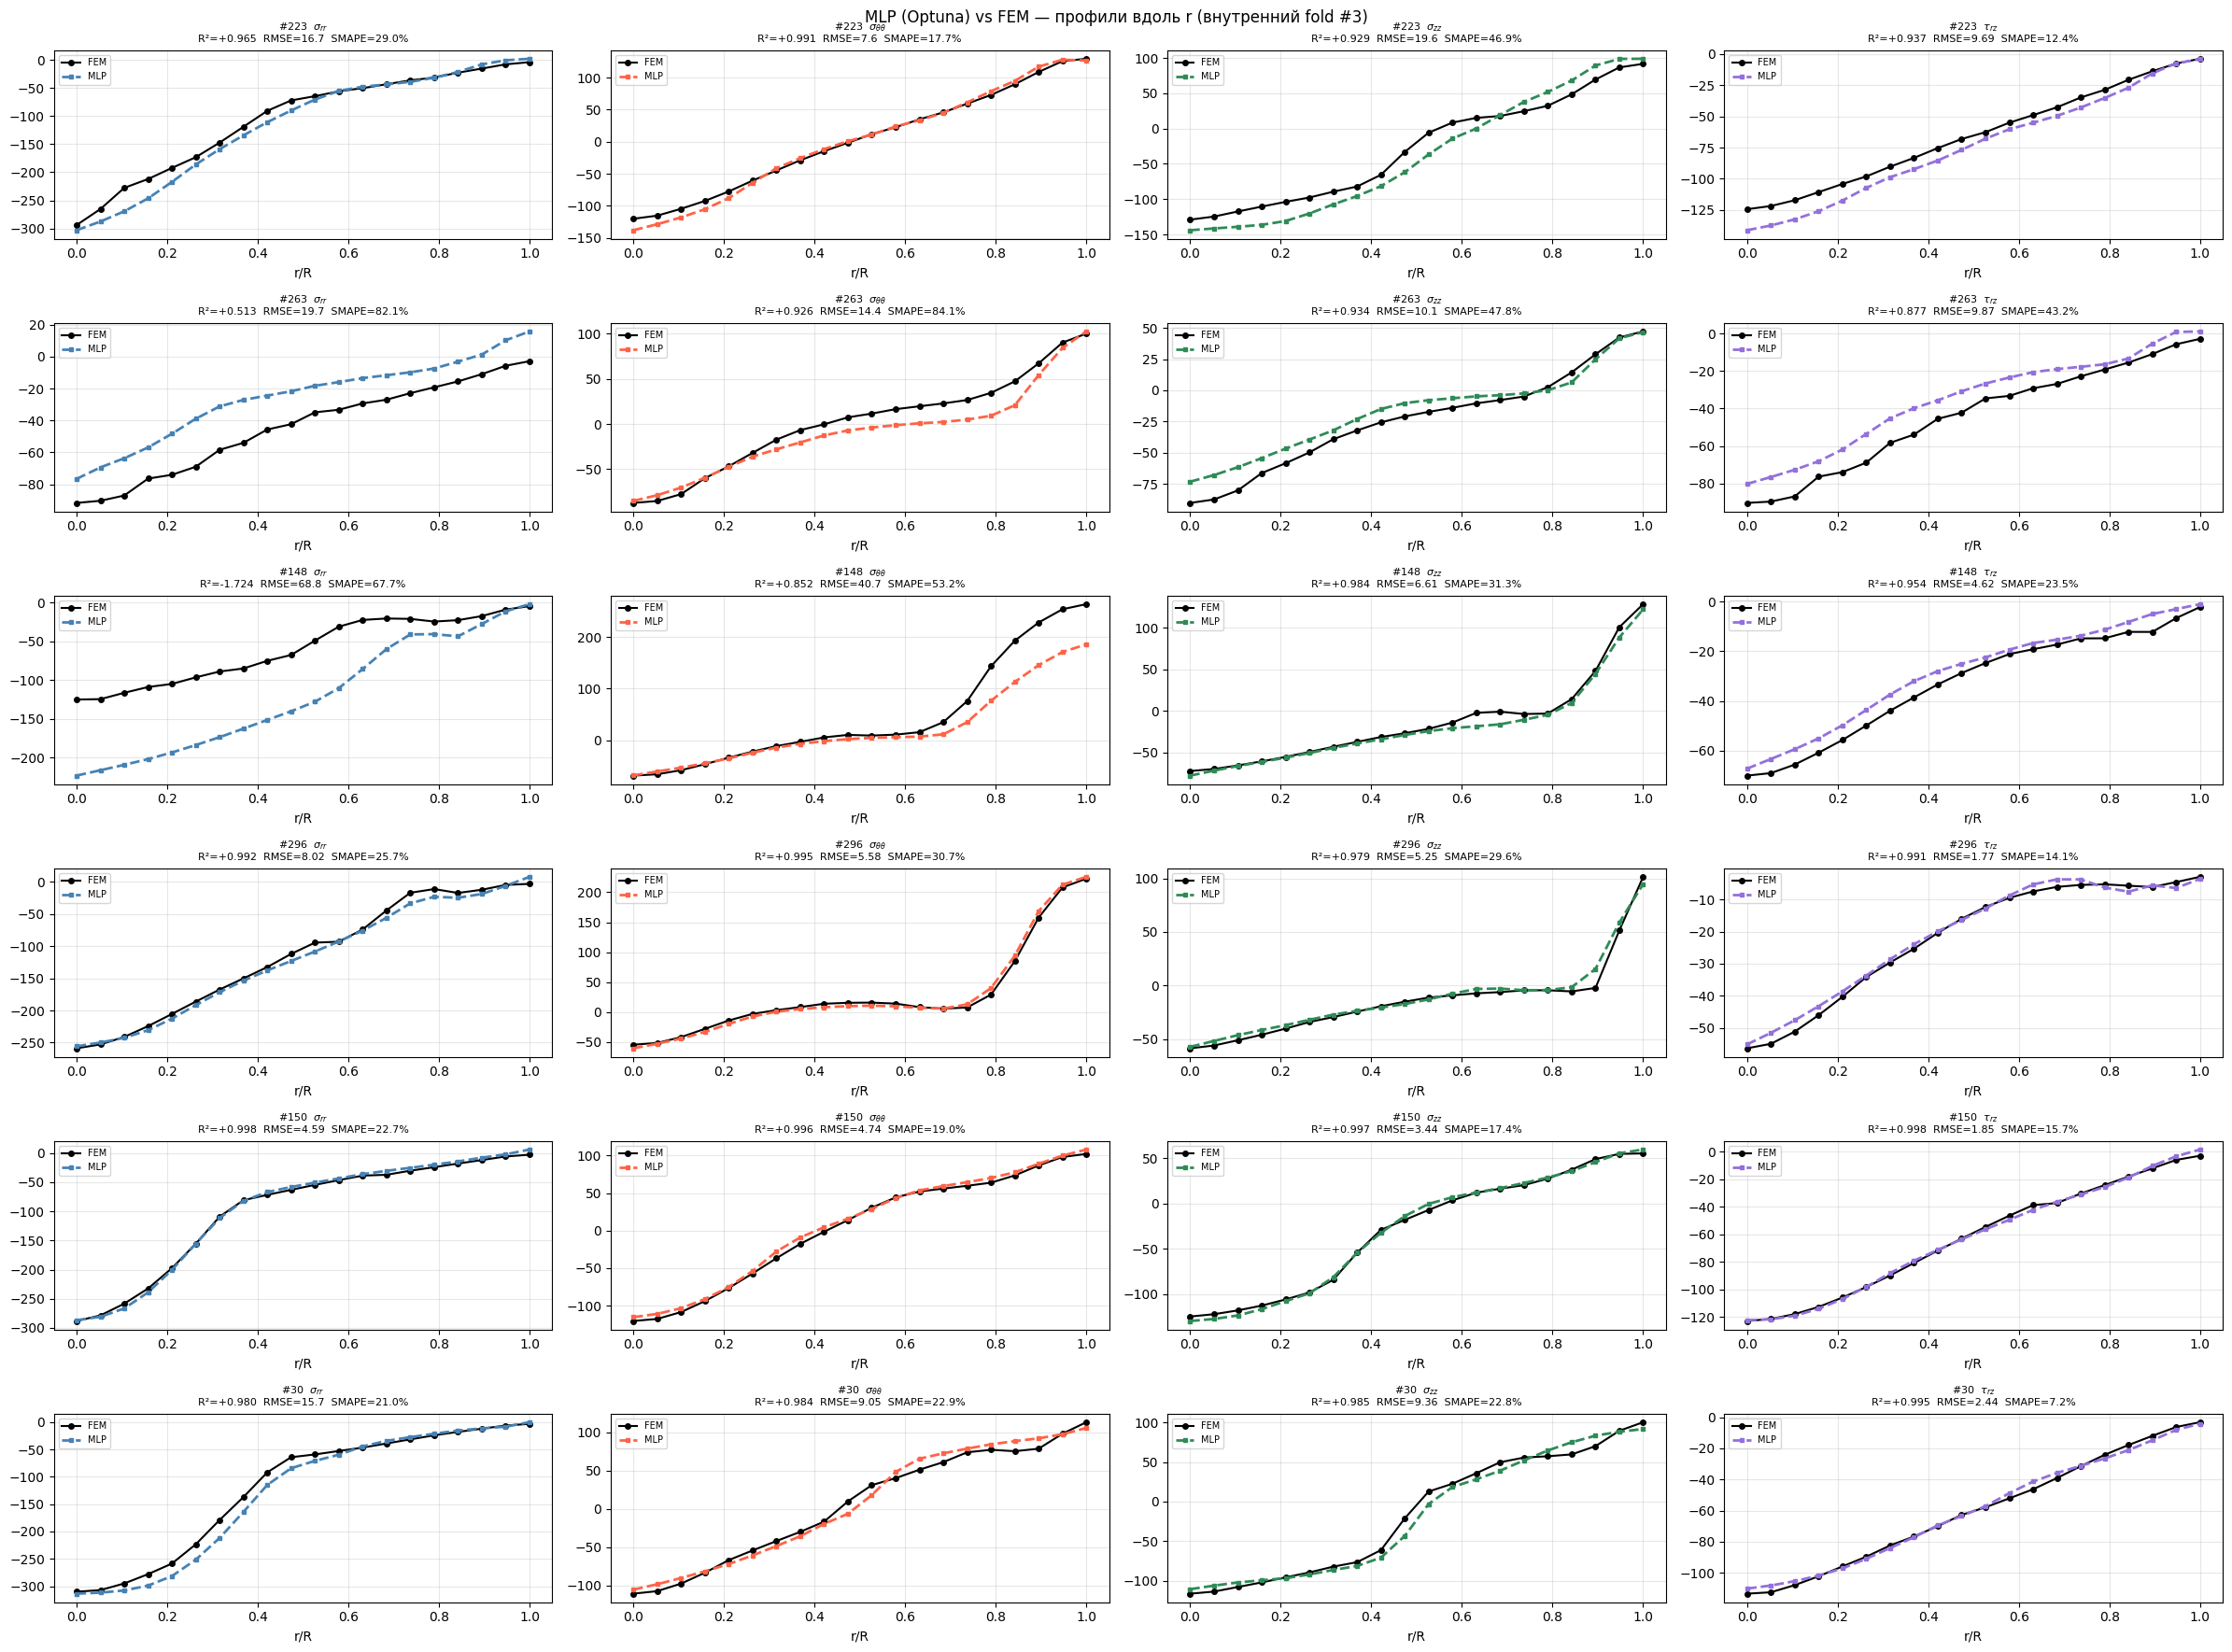

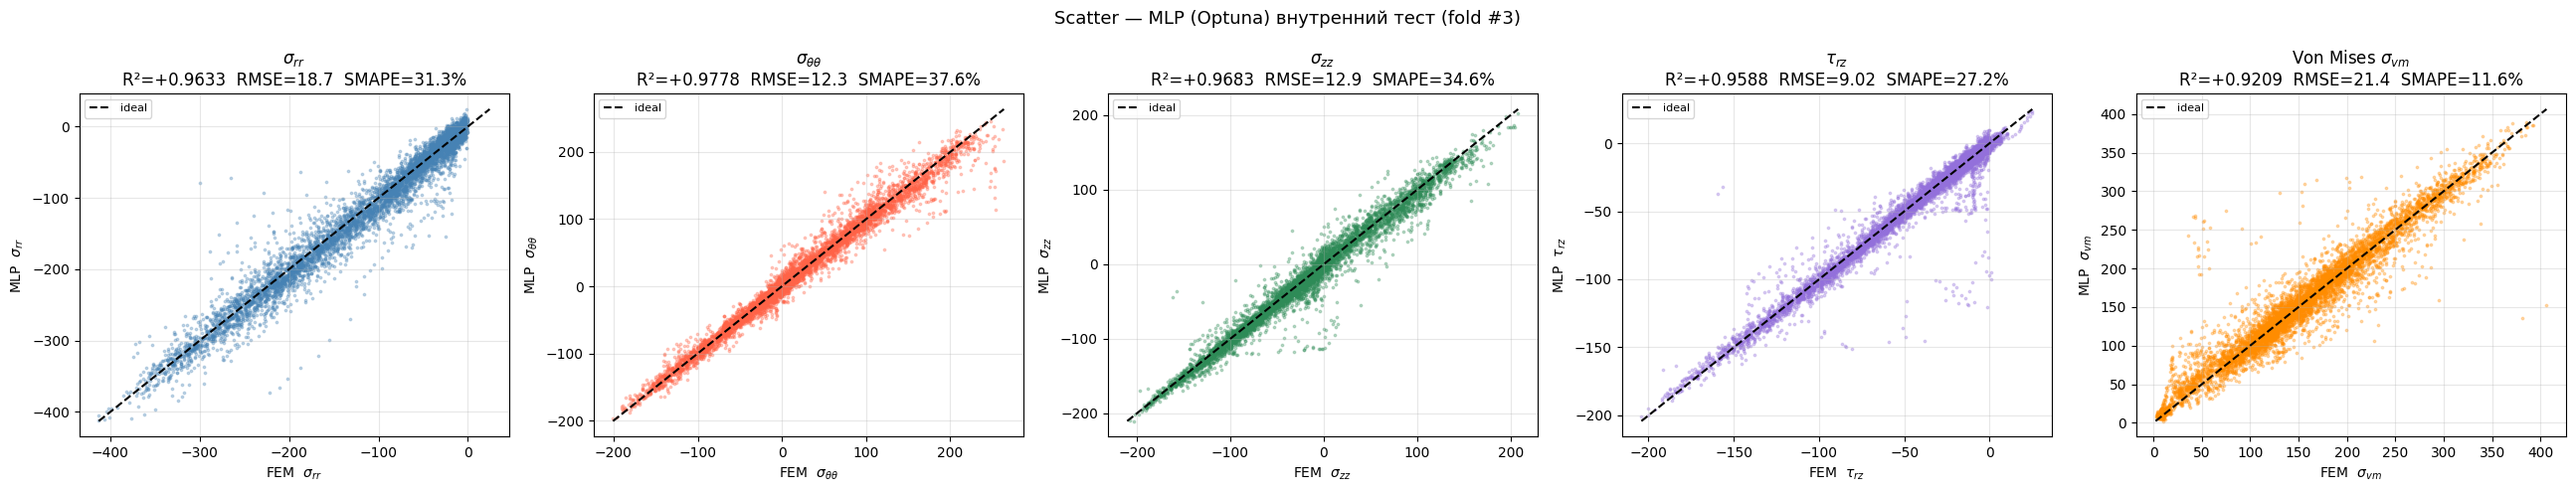


══════════════════════════════════════════════════════════════════════════
HOLDOUT VALIDATION  (304 sets, 6080 rows, 15.0% от total — never seen during training)
══════════════════════════════════════════════════════════════════════════

── Holdout — Metrics ───────────────────────────
  Explained Variance        : 0.9780
  Median AE                 : 4.7756
  MSE                       : 179.5577
  MAE                       : 7.7720
  R²                        : 0.9778
  Max Error                 : 190.4168
  AIC                       : 446494.3301
  BIC                       : 1576542.1753
  RMSE (4 comp macro)       : 12.6220
  Von Mises R²              : 0.9340
  SMAPE [%]                 : 31.8912

── Per-component RMSE / R² / SMAPE (Holdout (15% from cleaned train pkl)) ──
  sigma_rr    :  RMSE=     17.16   R²=+0.9686   SMAPE=  28.53%
  sigma_tt    :  RMSE=     15.99   R²=+0.9631   SMAPE=  37.52%
  sigma_zz    :  RMSE=     11.65   R²=+0.9739   SMAPE=  36.12%
  tau_rz      :  RMSE

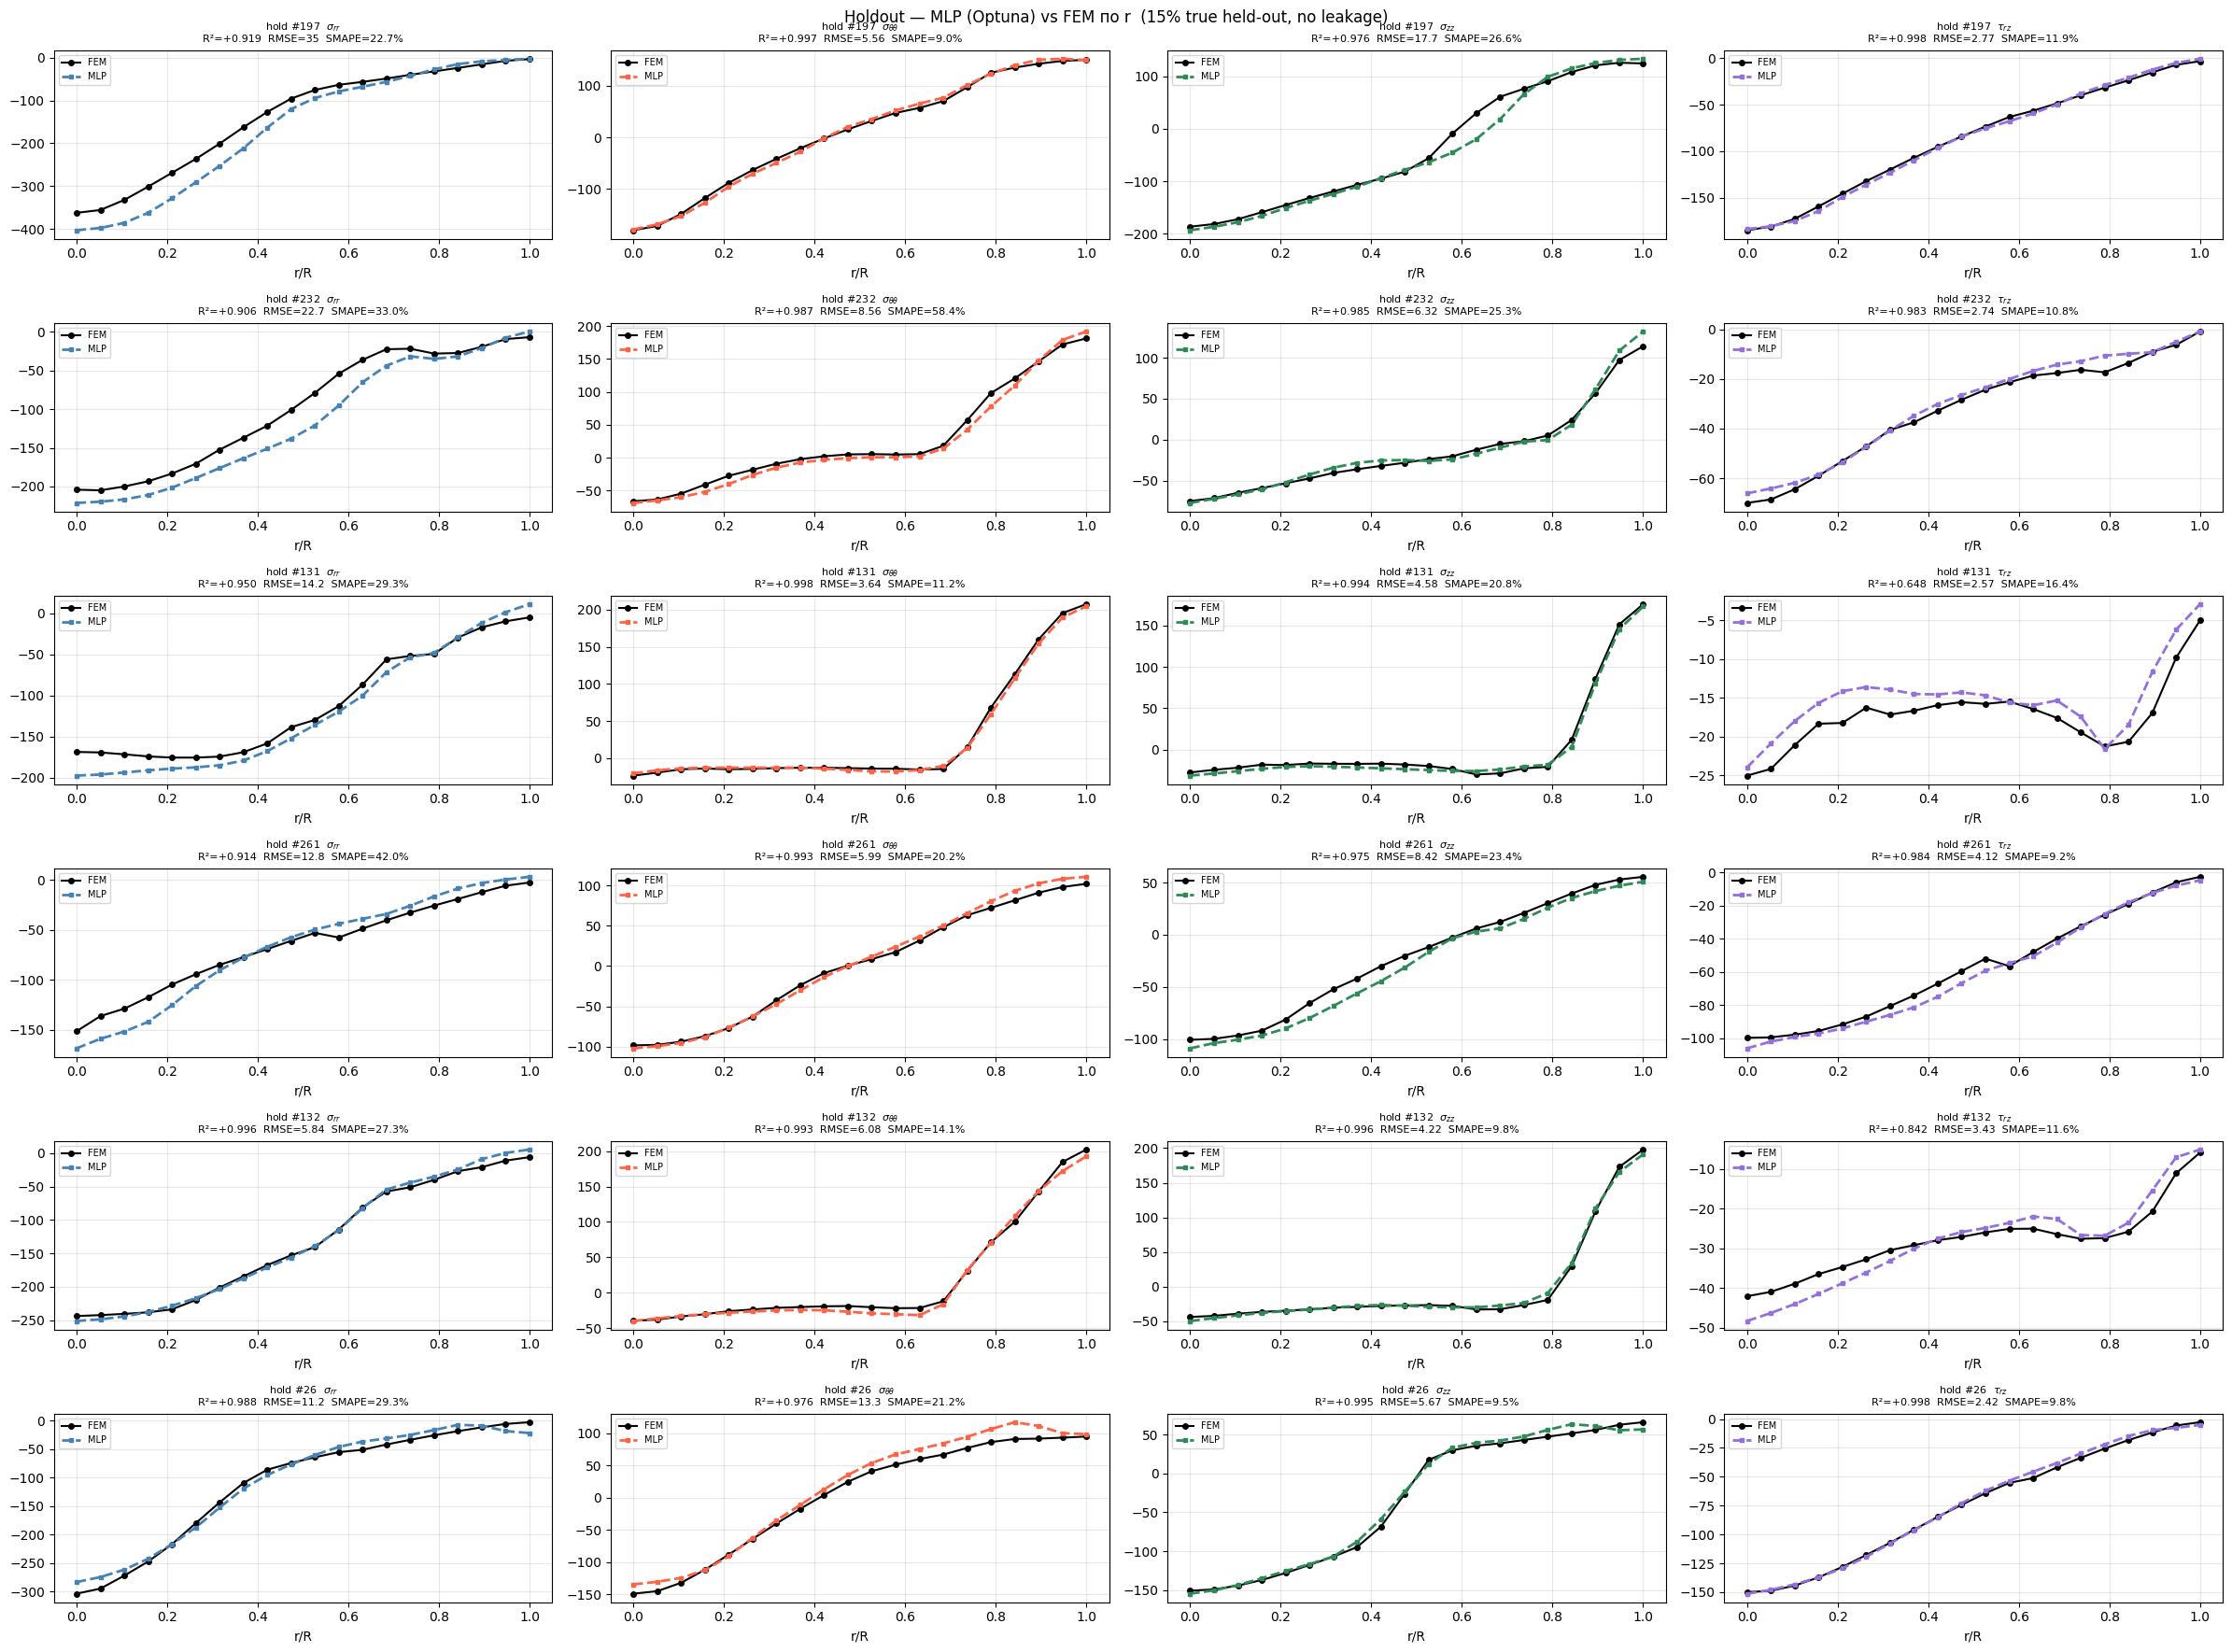

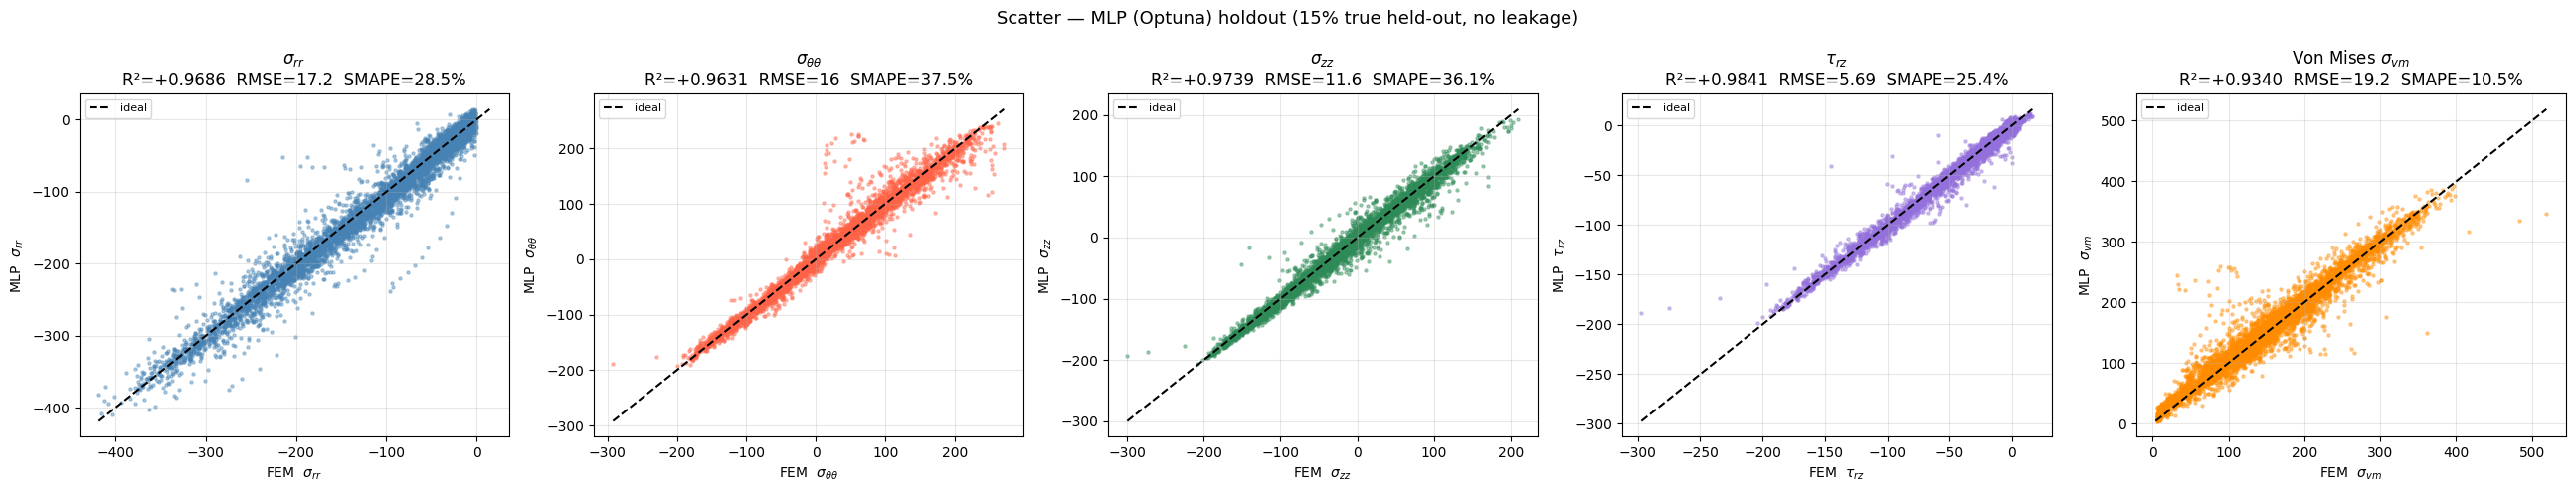


═══ MLP (Optuna) СВОДНАЯ ТАБЛИЦА  ═════════════════════════════════════
                     K-Fold mean  K-Fold std   Best Fold  Holdout 15%
Explained Variance      0.970108  0.00663297    0.977009     0.978004
Median AE                 4.5746    0.513244     4.85607      4.77563
MSE                      242.083      55.514     187.455      179.558
MAE                      8.16753    0.656993     8.10606      7.77203
R²                      0.969991  0.00664114    0.976799     0.977846
Max Error                268.846     51.5739     220.347      190.417
AIC                      418,272    5,962.92     411,867      446,494
BIC                  1.51847e+06    5,960.76 1.51205e+06  1.57654e+06
RMSE (4 comp macro)      14.9558      1.8038     13.2399       12.622
Von Mises R²              0.8923   0.0406395    0.920873     0.934012
SMAPE [%]                31.7855     2.13902     32.6725      31.8912

─── Время выполнения этапов ─────────────────────────────
  Optuna search        : 579

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ mlp_model.pkl


In [3]:
import importlib, pickle, time
from pathlib import Path
import mlp_model
importlib.reload(mlp_model)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import optuna
from sklearn.metrics import r2_score, mean_squared_error

from mlp_model import (
    build_stress_dataset,
    do_optuna_mlp,
    kfold_test_best_model_mlp,
    predict_with_mlp,
    cuml_scorer_mlp,
    per_component_report,
    von_mises_stress,
    smape,
    METRIC_NAMES,
    N_R,
    PLANE_ORDER,
    STRESS_COMPONENTS,
)


if not torch.cuda.is_available():
    raise RuntimeError(
        "\n\n❌ PyTorch не видит CUDA.\n\n"
        "   На Colab: Runtime → Change runtime type → A100 GPU → Save → Restart.\n"
    )
gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU detected: {gpu_name}  ({gpu_mem_gb:.1f} GB VRAM)")
print(f"  torch version  : {torch.__version__}")
print(f"  cuda available : {torch.cuda.is_available()}  (cuda version: {torch.version.cuda})")

IS_A100 = "A100" in gpu_name
if IS_A100:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    print(f"  → A100 detected: TF32 enabled, cudnn.benchmark=True")
print()


print("═" * 74)
print("ОБУЧАЮЩАЯ ВЫБОРКА  (X_stress.pkl / y_stress.pkl, cleaned, Abaqus convention, МПа)")
print("═" * 74)
X_pinn, y_pinn, r_grid, proc = build_stress_dataset(X_stress, y_stress, n_r=N_R)
n_sets_total = proc.shape[0]
print(f"  N_sets (всего)  : {n_sets_total}")
print(f"  rows total      : {X_pinn.shape[0]}  (= {n_sets_total} × {N_R})")
print(f"  (cleaned: удалены sets [78, 198, 204, 207, 210, 439, 449] из исходных 2035)")


print("\n" + "═" * 74)
print("HOLDOUT SPLIT  (≈70/15/15, group-aware, без data leakage)")
print("═" * 74)
HOLDOUT_FRAC = 0.15
SPLIT_SEED   = 42

rng = np.random.default_rng(SPLIT_SEED)
all_set_idx = np.arange(n_sets_total)
n_hold = max(1, int(round(n_sets_total * HOLDOUT_FRAC)))
hold_sets = np.sort(rng.choice(all_set_idx, size=n_hold, replace=False))
trainval_sets = np.sort(np.setdiff1d(all_set_idx, hold_sets))

def _rows_for_sets(sets: np.ndarray) -> np.ndarray:
    return np.concatenate([np.arange(s * N_R, (s + 1) * N_R) for s in sets])

hold_rows     = _rows_for_sets(hold_sets)
trainval_rows = _rows_for_sets(trainval_sets)

X_hold,     y_hold     = X_pinn[hold_rows],     y_pinn[hold_rows]
X_trainval, y_trainval = X_pinn[trainval_rows], y_pinn[trainval_rows]

assert len(set(hold_rows.tolist()) & set(trainval_rows.tolist())) == 0, \
    "data leakage: holdout и trainval пересекаются"
assert len(hold_sets) + len(trainval_sets) == n_sets_total

print(f"  HOLDOUT    : {len(hold_sets):4d} sets  ({len(hold_rows):5d} rows, "
      f"{100 * len(hold_sets) / n_sets_total:.1f}%)  ← never touched until end")
print(f"  TRAINVAL   : {len(trainval_sets):4d} sets  ({len(trainval_rows):5d} rows, "
      f"{100 * len(trainval_sets) / n_sets_total:.1f}%)")
print(f"  group-aware: все {N_R} r-точек одного set — в одной группе.")
print(f"  split_seed: {SPLIT_SEED}")


print(f"\n" + "═" * 74)
print("КОНФИГУРАЦИЯ MLP (data-driven baseline) + Optuna")
print("═" * 74)
N_TRIALS     = 20
N_INNER      = 1
N_FOLDS      = 5
N_LAYERS_MAX = 6
N_NEURONS    = 256

print(f"  АРХИТЕКТУРА  :")
print(f"    MLPNetwork — torch.nn.Sequential (Glorot normal init)")
print(f"    одна сеть, 4 outputs (σ_rr, σ_θθ, σ_zz, τ_rz)")
print(f"    smooth-only активации (tanh / selu / softplus)")
print(f"    torch.optim.AdamW с weight_decay")
print(f"")
print(f"  LOSS  :")
print(f"    L_MLP = L_data = mean(||y_pred - y_true||²) в scaled space")
print(f"    БЕЗ physics / BC / profile — только data MSE")
print(f"")
print(f"  search space (Optuna):")
print(f"    n_layers       : 3 … {N_LAYERS_MAX}")
print(f"    n_units_i      : 32 … {N_NEURONS}      (per layer)")
print(f"    activation     : tanh / selu / softplus")
print(f"    learning_rate  : 5e-5 … 2e-3   (log)")
print(f"    batch_size     : 16 / 32 / 64 / 128")
print(f"    max_epochs     : 200 … 600")
print(f"    optimizer      : Adam / AdamW")
print(f"    grad_clip      : 0.5 … 5.0")
print(f"    weight_decay   : 1e-5 … 1e-2     (log)")
print(f"  n_trials         : {N_TRIALS}")
print(f"  inner splits     : {N_INNER}        (worst-fold RMSE)")
print(f"  k-folds          : {N_FOLDS}        (group-aware, на TRAINVAL)")
print(f"  device           : {gpu_name} ({gpu_mem_gb:.1f} GB)")


print(f"\n" + "═" * 74)
print(f"OPTUNA SEARCH ({N_TRIALS} trials)")
print("═" * 74)
optuna.logging.set_verbosity(optuna.logging.INFO)

t_optuna_start = time.perf_counter()
best_params, _, _, best_inner_val = do_optuna_mlp(
    X_trainval, y_trainval,
    n_trials  = N_TRIALS,
    n_splits  = N_INNER,
    n_layers  = N_LAYERS_MAX,
    n_neurons = N_NEURONS,
)
t_optuna = time.perf_counter() - t_optuna_start

print(f"\n★ Optuna search закончен за {t_optuna:.1f} с  (≈ {t_optuna/N_TRIALS:.1f} с / trial)")
print(f"  best_inner_val (worst-fold macro RMSE): {best_inner_val:.4f}")
print(f"  best_params:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"    {k:18s} = {v:.6g}")
    else:
        print(f"    {k:18s} = {v}")


print(f"\n" + "═" * 74)
print(f"{N_FOLDS}-FOLD КРОСС-ВАЛИДАЦИЯ С ЛУЧШИМИ ГИПЕРПАРАМЕТРАМИ  (на TRAINVAL)")
print("═" * 74)

t_kfold_start = time.perf_counter()
kf = kfold_test_best_model_mlp(
    X_trainval, y_trainval, best_params,
    n_folds      = N_FOLDS,
    random_state = SPLIT_SEED,
)
t_kfold = time.perf_counter() - t_kfold_start

best_model    = kf["best_model"]
best_mean_X   = kf["best_mean_X"]
best_std_X    = kf["best_std_X"]
best_scaler_y = kf["best_scaler_y"]
best_history  = kf["best_history"]
best_fold_k   = kf["best_fold"]


pf = kf["per_fold_metrics"]
df = pd.DataFrame(pf, columns=METRIC_NAMES,
                  index=[f"Fold {i+1}" for i in range(N_FOLDS)])
df.loc["mean"] = pf.mean(axis=0)
df.loc["std"]  = pf.std(axis=0)

print("\n═══ MLP K-Fold per-fold metrics ════════════════════════════════════")
with pd.option_context("display.max_columns", None,
                       "display.width", 200,
                       "display.float_format", "{:,.4g}".format):
    print(df[["R²", "RMSE (4 comp macro)", "Von Mises R²", "SMAPE [%]", "MAE"]])

print(f"\n★ Лучший fold для ВКР: #{best_fold_k+1}")
print(f"   R²    = {pf[best_fold_k, 4]:+.4f}   RMSE  = {pf[best_fold_k, 8]:.4g}   "
      f"VM R² = {pf[best_fold_k, 9]:+.4f}")
print(f"   SMAPE = {pf[best_fold_k, 10]:.2f}%   MAE   = {pf[best_fold_k, 3]:.4g}")
print(f"   Эпох на лучшем fold: {len(best_history['train_losses'])}")
print(f"   K-Fold итоговое время: {t_kfold:.1f} с (≈ {t_kfold/N_FOLDS:.1f} с / fold)")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(best_history["train_losses"], label="Train", color="steelblue")
axes[0].plot(best_history["test_losses"],  label="Test",  color="tomato")
axes[0].set(xlabel="Epoch", ylabel="MSE (scaled)",
            title=f"Data loss — единственный компонент (fold #{best_fold_k+1}, "
                  f"{len(best_history['train_losses'])} epochs)",
            yscale="log")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(best_history["vm_rmse_test"], color="darkorange",
             label="Von Mises σ RMSE")
axes[1].set(xlabel="Epoch", ylabel="RMSE [МПа]", yscale="log",
            title="Von Mises σ RMSE — test")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f"MLP (data-only, Optuna) — кривые обучения "
             f"(лучший fold #{best_fold_k+1}, K-fold time {t_kfold:.1f} с)",
             fontsize=13)
plt.tight_layout(); plt.show()


comp_names = [r"$\sigma_{rr}$", r"$\sigma_{\theta\theta}$",
              r"$\sigma_{zz}$", r"$\tau_{rz}$"]
colors     = ["steelblue", "tomato", "seagreen", "mediumpurple"]

y_true_internal, y_pred_internal = kf["fold_test_arrays"][best_fold_k]
n_sets_internal = len(y_true_internal) // N_R

N_SHOW = min(6, n_sets_internal)
rng_show = np.random.default_rng(42)
show_idx_internal = rng_show.choice(n_sets_internal, size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(24, N_SHOW * 3))
for row, pi in enumerate(show_idx_internal):
    for col in range(4):
        ax = axes[row, col] if N_SHOW > 1 else axes[col]
        fem = y_true_internal[pi*N_R:(pi+1)*N_R, col]
        pnn = y_pred_internal[pi*N_R:(pi+1)*N_R, col]
        r2 = r2_score(fem, pnn); rm = np.sqrt(mean_squared_error(fem, pnn))
        sm = smape(fem, pnn)
        ax.plot(r_grid, fem, "o-",  color="black",     ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid, pnn, "s--", color=colors[col], ms=3, lw=2,   label="MLP")
        ax.set_title(f"#{pi}  {comp_names[col]}\n"
                     f"R²={r2:+.3f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%",
                     fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle(f"MLP (Optuna) vs FEM — профили вдоль r "
             f"(внутренний fold #{best_fold_k+1})", fontsize=12)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cname, clr) in enumerate(zip(comp_names, colors)):
    ax = axes[col]
    yt = y_true_internal[:, col]; yp = y_pred_internal[:, col]
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp))
    sm = smape(yt, yp)
    ax.scatter(yt, yp, s=3, alpha=0.3, color=clr)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    ax.set(xlabel=f"FEM  {cname}", ylabel=f"MLP  {cname}",
           title=f"{cname}\nR²={r2:+.4f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

vm_t = von_mises_stress(y_true_internal); vm_p = von_mises_stress(y_pred_internal)
ax = axes[4]
ax.scatter(vm_t, vm_p, s=3, alpha=0.3, color="darkorange")
lo = min(vm_t.min(), vm_p.min()); hi = max(vm_t.max(), vm_p.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
r2_vm = r2_score(vm_t, vm_p); rm_vm = np.sqrt(mean_squared_error(vm_t, vm_p))
sm_vm = smape(vm_t, vm_p)
ax.set(xlabel=r"FEM  $\sigma_{vm}$", ylabel=r"MLP  $\sigma_{vm}$",
       title=fr"Von Mises $\sigma_{{vm}}$"
             + f"\nR²={r2_vm:+.4f}  RMSE={rm_vm:.3g}  SMAPE={sm_vm:.1f}%")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle(f"Scatter — MLP (Optuna) внутренний тест (fold #{best_fold_k+1})",
             fontsize=13)
plt.tight_layout(); plt.show()


print("\n" + "═" * 74)
print(f"HOLDOUT VALIDATION  ({len(hold_sets)} sets, {len(hold_rows)} rows, "
      f"{100*len(hold_sets)/n_sets_total:.1f}% от total — never seen during training)")
print("═" * 74)

pred_dict = predict_with_mlp(
    best_model, X_hold,
    best_mean_X, best_std_X, best_scaler_y,
)
y_pred_hold = pred_dict["sigma"]

holdout_metrics = cuml_scorer_mlp(y_hold, y_pred_hold, best_model, X_trainval)

print(f"\n── Holdout — Metrics ───────────────────────────")
for n, v in zip(METRIC_NAMES, holdout_metrics):
    print(f"  {n:<26}: {v:.4f}")

per_component_report(y_hold, y_pred_hold, label="Holdout (15% from cleaned train pkl)")

print("\n── Post-eval sanity check: per-component R² ──")
component_r2_hold = []
catastrophic = []
for i, c in enumerate(STRESS_COMPONENTS):
    r2_c = r2_score(y_hold[:, i], y_pred_hold[:, i])
    component_r2_hold.append(r2_c)
    flag = " ⚠ CATASTROPHIC" if r2_c < -10 else ""
    if r2_c < -10:
        catastrophic.append((i, c, r2_c))
    print(f"  {c:10s}:  R² = {r2_c:+.4f}{flag}")
if catastrophic:
    print("\n  ❌ ВНИМАНИЕ: одна или несколько компонент имеют R² ≪ 0")
else:
    print("  ✓  Все 4 компоненты имеют R² > -10 — модель валидно обобщается на holdout")
    if any(r2 < 0 for r2 in component_r2_hold):
        neg = [c for c, r2 in zip(STRESS_COMPONENTS, component_r2_hold) if r2 < 0]
        print(f"  ℹ  Компоненты с R² < 0 ({', '.join(neg)}) — заметная heterogeneity сетов")

print("\n── BC-leak check: насколько MLP сам угадал traction-free BC? ──")
y_pred_hold_2d = y_pred_hold.reshape(len(hold_sets), N_R, 4)
at_r1_pred = y_pred_hold_2d[:, -1, :]
at_r1_fem  = y_hold.reshape(len(hold_sets), N_R, 4)[:, -1, :]
for col, lbl in [(0, "σ_rr"), (3, "τ_rz")]:
    pred_mean = at_r1_pred[:, col].mean()
    fem_mean  = at_r1_fem[:, col].mean()
    pred_max  = np.abs(at_r1_pred[:, col]).max()
    fem_max   = np.abs(at_r1_fem[:, col]).max()
    print(f"  {lbl} at r=1:  FEM mean={fem_mean:+.3g} max|.|={fem_max:.3g}  |  "
          f"MLP mean={pred_mean:+.3g} max|.|={pred_max:.3g}")


n_sets_hold = len(hold_sets)
N_SHOW_H = min(6, n_sets_hold)
show_idx_hold = np.random.default_rng(42).choice(n_sets_hold, size=N_SHOW_H, replace=False)

fig, axes = plt.subplots(N_SHOW_H, 4, figsize=(24, N_SHOW_H * 3))
for row, pi in enumerate(show_idx_hold):
    for col in range(4):
        ax = axes[row, col] if N_SHOW_H > 1 else axes[col]
        fem = y_hold[pi*N_R:(pi+1)*N_R, col]
        pnn = y_pred_hold[pi*N_R:(pi+1)*N_R, col]
        r2 = r2_score(fem, pnn); rm = np.sqrt(mean_squared_error(fem, pnn))
        sm = smape(fem, pnn)
        ax.plot(r_grid, fem, "o-",  color="black",     ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid, pnn, "s--", color=colors[col], ms=3, lw=2,   label="MLP")
        ax.set_title(f"hold #{pi}  {comp_names[col]}\n"
                     f"R²={r2:+.3f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%",
                     fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle(f"Holdout — MLP (Optuna) vs FEM по r  (15% true held-out, no leakage)",
             fontsize=12)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cname, clr) in enumerate(zip(comp_names, colors)):
    ax = axes[col]
    yt = y_hold[:, col]; yp = y_pred_hold[:, col]
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp))
    sm = smape(yt, yp)
    ax.scatter(yt, yp, s=5, alpha=0.4, color=clr)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    ax.set(xlabel=f"FEM  {cname}", ylabel=f"MLP  {cname}",
           title=f"{cname}\nR²={r2:+.4f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
vm_t = von_mises_stress(y_hold); vm_p = von_mises_stress(y_pred_hold)
ax = axes[4]
ax.scatter(vm_t, vm_p, s=5, alpha=0.4, color="darkorange")
lo = min(vm_t.min(), vm_p.min()); hi = max(vm_t.max(), vm_p.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
r2_vm = r2_score(vm_t, vm_p); rm_vm = np.sqrt(mean_squared_error(vm_t, vm_p))
sm_vm = smape(vm_t, vm_p)
ax.set(xlabel=r"FEM  $\sigma_{vm}$", ylabel=r"MLP  $\sigma_{vm}$",
       title=fr"Von Mises $\sigma_{{vm}}$"
             + f"\nR²={r2_vm:+.4f}  RMSE={rm_vm:.3g}  SMAPE={sm_vm:.1f}%")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Scatter — MLP (Optuna) holdout (15% true held-out, no leakage)",
             fontsize=13)
plt.tight_layout(); plt.show()


summary = pd.DataFrame({
    "K-Fold mean": kf["mean"],
    "K-Fold std":  kf["std"],
    "Best Fold":   pf[best_fold_k],
    "Holdout 15%": holdout_metrics,
}, index=METRIC_NAMES)
print("\n═══ MLP (Optuna) СВОДНАЯ ТАБЛИЦА  ═════════════════════════════════════")
with pd.option_context("display.max_columns", None,
                       "display.width", 200,
                       "display.float_format", "{:,.6g}".format):
    print(summary)

print("\n─── Время выполнения этапов ─────────────────────────────")
print(f"  Optuna search        : {t_optuna:.1f} с   "
      f"({N_TRIALS} trials, ≈ {t_optuna/N_TRIALS:.1f} с / trial)")
print(f"  K-Fold ({N_FOLDS} folds)     : {t_kfold:.1f} с   "
      f"(≈ {t_kfold/N_FOLDS:.1f} с / fold)")
print(f"  best fold (#{best_fold_k+1})         : epochs={len(best_history['train_losses'])}")
print(f"  ИТОГО (search + CV)  : {t_optuna + t_kfold:.1f} с")


ART_DIR = Path("./artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ART_DIR / "mlp_model.pkl"

n_lay = best_params["n_layers"]
units = [best_params[f"n_units_{i}"] for i in range(n_lay)]

torch_state_dict = {
    k: v.detach().cpu().numpy() for k, v in best_model.state_dict().items()
}
mean_X_np = (best_mean_X.detach().cpu().numpy()
             if isinstance(best_mean_X, torch.Tensor) else np.asarray(best_mean_X))
std_X_np  = (best_std_X.detach().cpu().numpy()
             if isinstance(best_std_X,  torch.Tensor) else np.asarray(best_std_X))

bundle = {
    "version":               "mlp_optuna_holdout_v2_cleaned",
    "framework":             "pytorch_mlp_baseline_optuna",
    "torch_version":         torch.__version__,
    "torch_state_dict":      torch_state_dict,
    "best_params":           best_params,
    "layer_widths":          units,
    "activation":            best_params["activation"],
    "layer_sizes":           [6] + units + [4],
    "mean_X":                mean_X_np,
    "std_X":                 std_X_np,
    "scaler_y_mean":         best_scaler_y.mean_,
    "scaler_y_std":          best_scaler_y.std_,
    "best_fold":             best_fold_k,
    "best_n_epochs":         len(best_history["train_losses"]),
    "kfold_metrics":         kf["per_fold_metrics"],
    "kfold_mean":            kf["mean"],
    "kfold_std":             kf["std"],
    "best_history":          best_history,
    "holdout_set_indices":   hold_sets,
    "trainval_set_indices":  trainval_sets,
    "holdout_frac":          HOLDOUT_FRAC,
    "split_seed":            SPLIT_SEED,
    "holdout_metrics":       holdout_metrics,
    "holdout_per_component_r2": np.asarray(component_r2_hold),
    "metric_names":          METRIC_NAMES,
    "removed_set_indices":   [78, 198, 204, 207, 210, 439, 449],
    "tuner":                 "optuna",
    "n_trials":              N_TRIALS,
    "best_inner_val":        best_inner_val,
    "mlp_config": {
        "architecture":     "torch.nn.Sequential (Glorot normal, single network, "
                            "4 outputs)",
        "loss":             "L_data = mean(||y_pred - y_true||²) — DATA ONLY",
        "physics":          "NONE (no equilibrium, no BC, no profile loss)",
        "tuner":            "Optuna TPE sampler (n_trials={N_TRIALS})".format(
                              N_TRIALS=N_TRIALS),
        "split_strategy":   "≈70/15/15 group-aware: 15% holdout removed "
                            "BEFORE Optuna/K-fold; trainval split internally",
    },
    "optuna_time_sec":       t_optuna,
    "kfold_time_sec":        t_kfold,
    "plane_order":           PLANE_ORDER,
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)

DRIVE_ROOT = Path("/content/drive/MyDrive")
if DRIVE_ROOT.exists():
    DRIVE_BACKUP = DRIVE_ROOT / "pinn_artifacts"
    DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
    drive_path = DRIVE_BACKUP / MODEL_PATH.name
    import shutil
    shutil.copy2(MODEL_PATH, drive_path)
    drive_msg = f"  Бэкап в Drive: {drive_path}"
else:
    drive_msg = ("  Drive не смонтирован — для автобэкапа выполни в новой ячейке:\n"
                 "    from google.colab import drive; drive.mount('/content/drive')")

print(f"\n✓ MLP (Optuna) модель сохранена → {MODEL_PATH.resolve()}")
print(f"  Размер файла : {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print(f"  Лучший fold  : #{best_fold_k+1}    "
      f"(epochs={len(best_history['train_losses'])})")
print(f"  Архитектура  : {units}  ({best_params['activation']})")
print(f"  Optimizer    : {best_params['optimizer']}(lr={best_params['learning_rate']:.4g}, "
      f"wd={best_params.get('weight_decay', 1e-4):.4g})")
print(f"  Loss         : data MSE only — БЕЗ physics/BC/profile")
print(f"  Tuner        : Optuna TPE ({N_TRIALS} trials)")
print(f"  Search time  : {t_optuna:.1f} с / {N_TRIALS} trials")
print(f"  Holdout R²   : {holdout_metrics[4]:+.4f}   "
      f"VM R²: {holdout_metrics[9]:+.4f}   "
      f"RMSE: {holdout_metrics[8]:.3f}   SMAPE: {holdout_metrics[10]:.2f}%")
print(f"  Backend      : pure PyTorch ({torch.__version__}) on {gpu_name}")
print(drive_msg)


try:
    from google.colab import files
    print("\n→ Скачиваю mlp_model.pkl на локальный Downloads…")
    files.download(str(MODEL_PATH))
    print(f"  ✓ {MODEL_PATH.name}")
except ImportError:
    print(f"\nℹ Не Colab — файл доступен напрямую: {MODEL_PATH.resolve()}")
except Exception as e:
    print(f"\n⚠ Скачивание не удалось: {e}")
    print(f"  Файл лежит на диске: {MODEL_PATH.resolve()}")

══════════════════════════════════════════════════════════════════════════
WORST-PREDICTIONS AUDIT  —  MLP (Optuna)
══════════════════════════════════════════════════════════════════════════
  device         : cuda
  layer_sizes    : [6, 207, 246, 238, 92, 4]
  activation     : tanh
  tuner          : optuna  (n_trials=20)
  holdout sets   : 304  (sorted indices, seed=42)
  holdout rows   : 6080
  removed earlier: [78, 198, 204, 207, 210, 439, 449]  (исходная Abaqus-индексация)

  X_hold         : (6080, 6)    [Q, k, α, μ, v, r_norm]
  y_hold         : (6080, 4)    [σ_rr, σ_θθ, σ_zz, τ_rz]  (после PLANE_ORDER)
  y_pred         : (6080, 4)

  WORST_FRAC      : 5.0%
  n_worst (per component): 304 строк из 6080


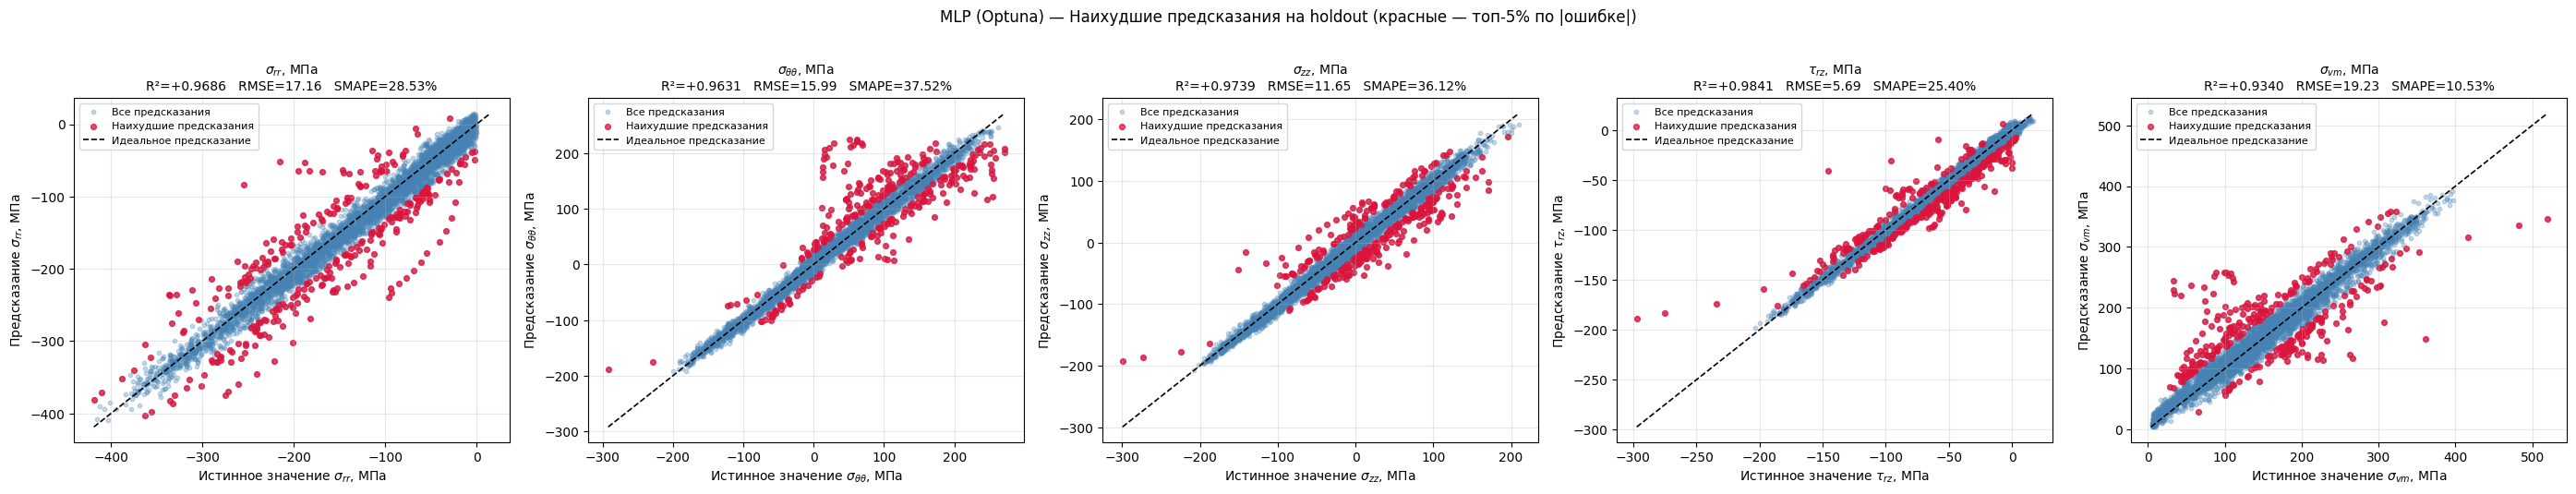


══════════════════════════════════════════════════════════════════════════
ПОКОМПОНЕНТНЫЕ ТАБЛИЦЫ НАИХУДШИХ ПРЕДСКАЗАНИЙ
══════════════════════════════════════════════════════════════════════════

── Топ-10 наихудших по $\sigma_{rr}$, МПа  (из 304 всего) ──
 set_id  r_idx     Q    k  alpha    mu   v       r  y_true  y_pred  abs_err  rel_err_%
    204     17  0.25  0.3     12  0.05  10  0.8947  -255.2  -83.43    171.7      67.31
    315     18   0.2 0.75     16 0.025  10  0.9474    -215  -51.57    163.4      76.01
   1646      0 0.025  0.3     20  0.05 250       0  -95.75  -238.9    143.2      149.5
   1646      1 0.025  0.3     20  0.05 250 0.05263  -93.17  -232.9    139.7        150
   1646      4 0.025  0.3     20  0.05 250  0.2105  -76.72  -212.3    135.6      176.7
    302     18   0.2    1     16   0.1  10  0.9474  -187.6  -52.36    135.2      72.09
   1646      3 0.025  0.3     20  0.05 250  0.1579  -84.78    -220    135.2      159.4
   1646      5 0.025  0.3     20  0.05 250  0

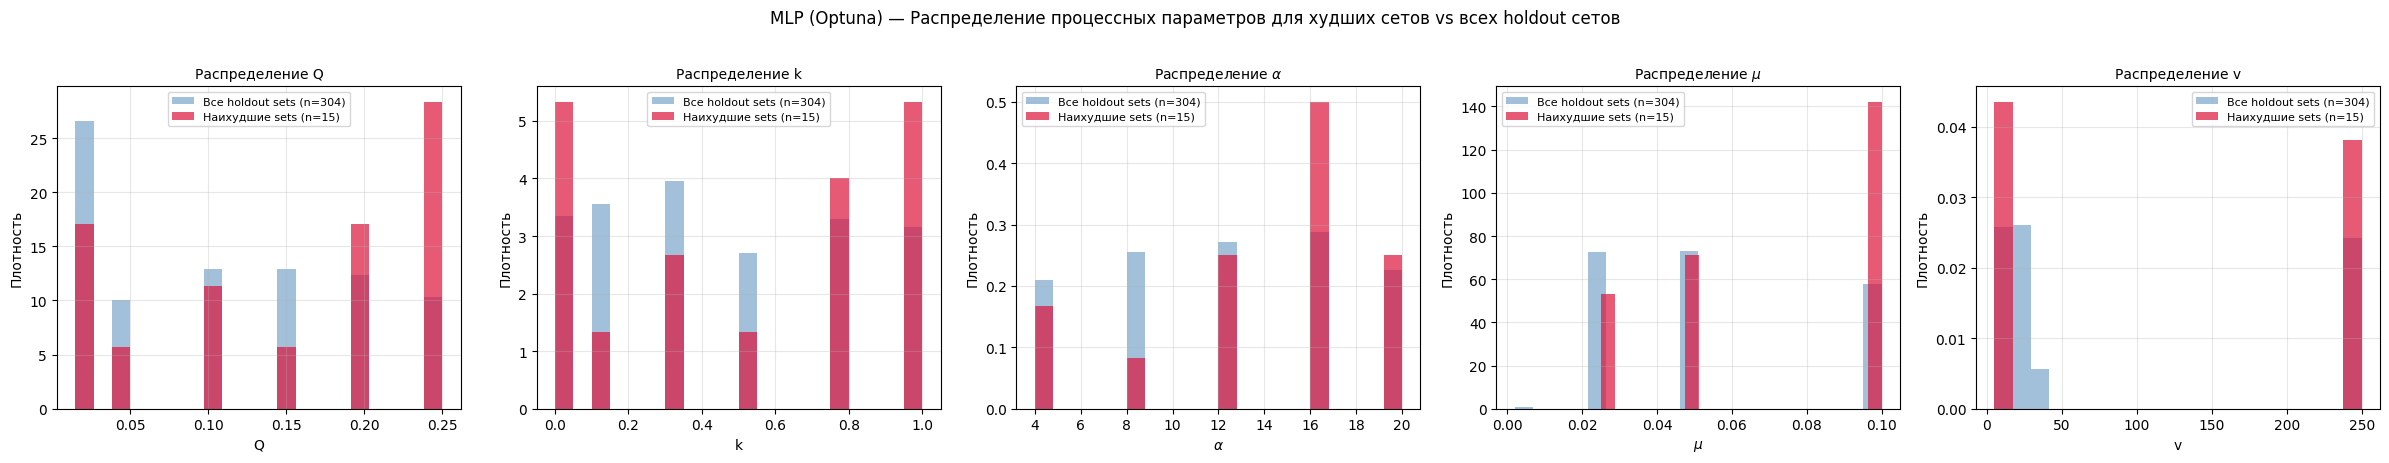

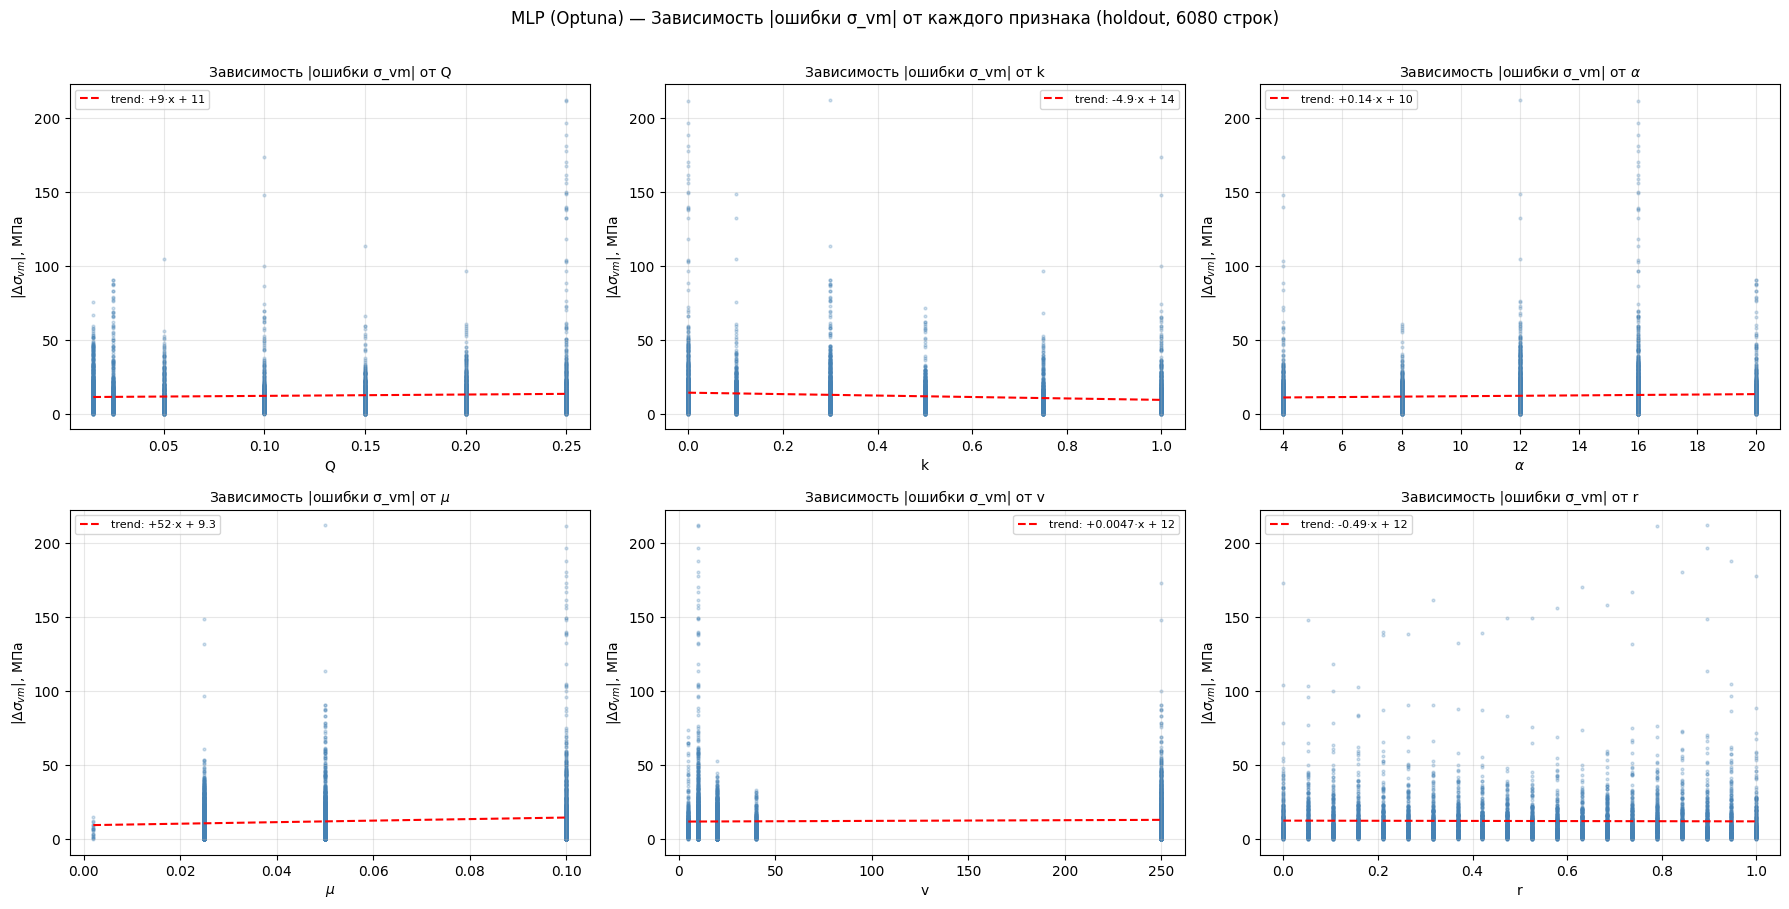


══════════════════════════════════════════════════════════════════════════
ОШИБКИ В ГРАНИЧНЫХ vs ВНУТРЕННИХ ТОЧКАХ ПРОЦЕССНОГО ПРОСТРАНСТВА
══════════════════════════════════════════════════════════════════════════
  граничные сеты :  304  (100.0% holdout), mean |err|_macro = 7.77 МПа
  внутренние сеты:    0  (0.0% holdout), mean |err|_macro = nan МПа

✓ Сохранено: worst_sets_mlp_optuna.csv  (15 строк — таблица для подраздела «Аудит выбросов»)
✓ Сохранено: all_holdout_sets_errors_mlp_optuna.csv  (304 строк — полная таблица per-set ошибок)

══════════════════════════════════════════════════════════════════════════
AUDIT ЗАВЕРШЁН. Файлы для ВКР: worst_predictions_scatter_mlp_optuna.png, worst_sets_param_histograms_mlp_optuna.png, error_vs_features_mlp_optuna.png, worst_sets_mlp_optuna.csv, all_holdout_sets_errors_mlp_optuna.csv
══════════════════════════════════════════════════════════════════════════


/tmp/ipykernel_1091/3221083311.py:308: RuntimeWarning: Mean of empty slice.
  f"mean |err|_macro = {inn_err.mean():.2f} МПа")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
"""launch cell — Worst-Predictions Audit для MLP (Optuna baseline).

Воспроизводит подход магистерской ВКР (gradient_boosting.ipynb, секция
«Анализ наихудших предсказаний модели») для data-driven MLP-модели
с Optuna-подобранными гиперпараметрами на holdout-наборе.

Структура идентична audit-скрипту для MLP grid search и PINN[PyTorch] —
тот же подход, только импорты из mlp_model (Optuna версия) и путь к
mlp_model.pkl.

Что делает:
    1) загружает обученный mlp_model.pkl + holdout indices,
    2) реконструирует архитектуру и предсказывает holdout-точки,
    3) находит топ-5% наихудших предсказаний (по абсолютной ошибке) в МПа,
    4) рисует scatter «истинное vs предсказание» — синие все точки,
       красные топ-5% (калька фигуры из магистерской ВКР),
    5) выводит таблицы топ-10 наихудших по 4 компонентам + σ_vm,
    6) делает per-set агрегацию (mean/max |err| по 20 r-точкам set'а),
    7) гистограммы процессных параметров: худшие sets vs все holdout sets,
    8) error vs feature scatter с линиями тренда.

Перед запуском:
    /content/mlp_model.py     — рабочий модуль (с do_optuna_mlp)
    /content/mlp_model.pkl    — обученный bundle (cleaned data)
    X_stress / y_stress       — уже в namespace (cleaned)
"""
import importlib
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import r2_score, mean_squared_error

import mlp_model
importlib.reload(mlp_model)
from mlp_model import (
    build_stress_dataset,
    predict_with_mlp,
    von_mises_stress,
    smape,
    OutputScaler,
    MLPNetwork,
    N_R,
    PLANE_ORDER,
    STRESS_COMPONENTS,
)

MODEL_TAG  = "MLP (Optuna)"
MODEL_PATH = Path("./artifacts/mlp_model.pkl")
WORST_FRAC = 0.05                                                          # топ-5% от holdout, как в магистерской работе


print("═" * 74)
print(f"WORST-PREDICTIONS AUDIT  —  {MODEL_TAG}")
print("═" * 74)

with open(MODEL_PATH, "rb") as f:
    bundle = pickle.load(f)

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
layer_sizes = bundle["layer_sizes"]
activation  = bundle["activation"]
state_dict  = {k: torch.from_numpy(v) for k, v in bundle["torch_state_dict"].items()}

model = MLPNetwork(layer_sizes, activation=activation).to(device)
model.load_state_dict({k: v.to(device) for k, v in state_dict.items()})
model.eval()

mean_X = torch.from_numpy(bundle["mean_X"]).to(device)
std_X  = torch.from_numpy(bundle["std_X"]).to(device)
scaler_y = OutputScaler()
scaler_y.mean_ = bundle["scaler_y_mean"]
scaler_y.std_  = bundle["scaler_y_std"]

hold_sets   = bundle["holdout_set_indices"]
plane_order = bundle["plane_order"]
already_removed = bundle.get("removed_set_indices", [])
assert plane_order == PLANE_ORDER, "PLANE_ORDER mismatch (см. wire-drawing-surrogate skill)"

print(f"  device         : {device}")
print(f"  layer_sizes    : {layer_sizes}")
print(f"  activation     : {activation}")
print(f"  tuner          : {bundle.get('tuner', 'optuna')}  "
      f"(n_trials={bundle.get('n_trials', '?')})")
print(f"  holdout sets   : {len(hold_sets)}  (sorted indices, seed={bundle['split_seed']})")
print(f"  holdout rows   : {len(hold_sets) * N_R}")
print(f"  removed earlier: {already_removed}  (исходная Abaqus-индексация)")


X_pinn, y_pinn, r_grid, proc_all = build_stress_dataset(
    X_stress, y_stress, n_r=N_R, verbose=False,
)
hold_rows = np.concatenate([np.arange(s * N_R, (s + 1) * N_R) for s in hold_sets])
X_hold = X_pinn[hold_rows]
y_hold = y_pinn[hold_rows]

pred = predict_with_mlp(model, X_hold, mean_X, std_X, scaler_y)
y_pred  = pred["sigma"]
vm_true = von_mises_stress(y_hold)
vm_pred = von_mises_stress(y_pred)

print(f"\n  X_hold         : {X_hold.shape}    [Q, k, α, μ, v, r_norm]")
print(f"  y_hold         : {y_hold.shape}    [σ_rr, σ_θθ, σ_zz, τ_rz]  (после PLANE_ORDER)")
print(f"  y_pred         : {y_pred.shape}")


FEATURE_NAMES = ["Q", "k", r"$\alpha$", r"$\mu$", "v", "r"]
FEATURE_KEYS  = ["Q", "k", "alpha", "mu", "v", "r"]

set_id_per_row = np.repeat(hold_sets, N_R)
r_idx_per_row  = np.tile(np.arange(N_R), len(hold_sets))

abs_err    = np.abs(y_hold - y_pred)
abs_err_vm = np.abs(vm_true - vm_pred)
eps_rel    = 1.0                                                           # МПа, ниже этой амплитуды rel-err теряет смысл
rel_err    = 100.0 * abs_err / np.maximum(np.abs(y_hold), eps_rel)

base_df = pd.DataFrame({
    "set_id": set_id_per_row,
    "r_idx":  r_idx_per_row,
    **{FEATURE_KEYS[i]: X_hold[:, i] for i in range(6)},
})


comp_titles = [
    r"$\sigma_{rr}$, МПа",
    r"$\sigma_{\theta\theta}$, МПа",
    r"$\sigma_{zz}$, МПа",
    r"$\tau_{rz}$, МПа",
    r"$\sigma_{vm}$, МПа",
]
comp_data = [
    (y_hold[:, 0], y_pred[:, 0], abs_err[:, 0]),
    (y_hold[:, 1], y_pred[:, 1], abs_err[:, 1]),
    (y_hold[:, 2], y_pred[:, 2], abs_err[:, 2]),
    (y_hold[:, 3], y_pred[:, 3], abs_err[:, 3]),
    (vm_true,      vm_pred,      abs_err_vm),
]

n_total = len(y_hold)
n_worst = max(int(n_total * WORST_FRAC), 10)
print(f"\n  WORST_FRAC      : {WORST_FRAC:.1%}")
print(f"  n_worst (per component): {n_worst} строк из {n_total}")

fig, axes = plt.subplots(1, 5, figsize=(28, 5.2))
worst_indices_per_comp = {}

for ax, title, (yt, yp, ae) in zip(axes, comp_titles, comp_data):
    wi = np.argsort(ae)[-n_worst:]
    worst_indices_per_comp[title] = wi
    ax.scatter(yt, yp, s=10, alpha=0.3, color="steelblue",
                label="Все предсказания")
    ax.scatter(yt[wi], yp[wi], s=18, alpha=0.75, color="crimson",
                label="Наихудшие предсказания")
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Идеальное предсказание")
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp)); sm = smape(yt, yp)
    ax.set_xlabel(f"Истинное значение {title}")
    ax.set_ylabel(f"Предсказание {title}")
    ax.set_title(f"{title}\nR²={r2:+.4f}   RMSE={rm:.2f}   SMAPE={sm:.2f}%",
                 fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc="best")

plt.suptitle(f"{MODEL_TAG} — Наихудшие предсказания на holdout "
             f"(красные — топ-{WORST_FRAC:.0%} по |ошибке|)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("worst_predictions_scatter_mlp_optuna.png", dpi=300, bbox_inches="tight")
plt.show()


def make_worst_table(title, yt, yp, ae, n_show=10):
    wi = np.argsort(ae)[-n_worst:]
    df = base_df.iloc[wi].copy()
    df["y_true"]    = yt[wi]
    df["y_pred"]    = yp[wi]
    df["abs_err"]   = ae[wi]
    df["rel_err_%"] = 100.0 * ae[wi] / np.maximum(np.abs(yt[wi]), eps_rel)
    df = df.sort_values("abs_err", ascending=False).reset_index(drop=True)
    print(f"\n── Топ-{n_show} наихудших по {title}  (из {n_worst} всего) ──")
    with pd.option_context("display.max_columns", None, "display.width", 200,
                            "display.float_format", "{:,.4g}".format):
        print(df.head(n_show).to_string(index=False))
    return df

print("\n" + "═" * 74)
print("ПОКОМПОНЕНТНЫЕ ТАБЛИЦЫ НАИХУДШИХ ПРЕДСКАЗАНИЙ")
print("═" * 74)
worst_tables = {t: make_worst_table(t, yt, yp, ae, n_show=10)
                 for t, (yt, yp, ae) in zip(comp_titles, comp_data)}


print("\n" + "═" * 74)
print("PER-SET АГРЕГАЦИЯ — mean / max |err| по 20 r-точкам одного FEM-расчёта")
print("═" * 74)

ae_by_set      = abs_err.reshape(len(hold_sets), N_R, 4)
ae_by_set_mean = ae_by_set.mean(axis=1)
ae_by_set_max  = ae_by_set.max(axis=1)
ae_vm_by_set   = abs_err_vm.reshape(len(hold_sets), N_R)
ae_vm_set_mean = ae_vm_by_set.mean(axis=1)
ae_vm_set_max  = ae_vm_by_set.max(axis=1)

set_df = pd.DataFrame({"set_id": hold_sets})
for i, key in enumerate(FEATURE_KEYS[:5]):
    set_df[key] = proc_all[hold_sets, i]
for i, name in enumerate(STRESS_COMPONENTS):
    set_df[f"mean_err_{name}"] = ae_by_set_mean[:, i]
    set_df[f"max_err_{name}"]  = ae_by_set_max[:, i]
set_df["mean_err_vm"]    = ae_vm_set_mean
set_df["max_err_vm"]     = ae_vm_set_max
set_df["mean_err_macro"] = ae_by_set_mean.mean(axis=1)

n_worst_sets = max(int(len(hold_sets) * WORST_FRAC), 5)
worst_sets_df = set_df.nlargest(n_worst_sets, "mean_err_macro").reset_index(drop=True)
print(f"\nТоп-{n_worst_sets} наихудших СЕТОВ holdout (по mean_err_macro = "
      f"средняя |err| по 4 компонентам и 20 r-точкам):")
with pd.option_context("display.max_columns", None, "display.width", 220,
                        "display.float_format", "{:,.4g}".format):
    cols_show = ["set_id", "Q", "k", "alpha", "mu", "v",
                  "mean_err_macro", "mean_err_vm", "max_err_vm"]
    print(worst_sets_df[cols_show].to_string(index=False))

print(f"\n  ✓ Все ранее обнаруженные FEM-артефакты {already_removed} удалены из")
print(f"    обучающей выборки до тренировки модели.")
print(f"    Текущие 'наихудшие' sets отражают edge-of-distribution регионы")
print(f"    параметрического пространства, а не дефекты данных.")


fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
param_labels = ["Q", "k", r"$\alpha$", r"$\mu$", "v"]

for ax, key, label in zip(axes, FEATURE_KEYS[:5], param_labels):
    all_vals   = set_df[key].values
    worst_vals = worst_sets_df[key].values
    bins = 20
    ax.hist(all_vals, bins=bins, alpha=0.5, color="steelblue",
            label=f"Все holdout sets (n={len(all_vals)})", density=True)
    ax.hist(worst_vals, bins=bins, alpha=0.7, color="crimson",
            label=f"Наихудшие sets (n={len(worst_vals)})", density=True)
    ax.set_xlabel(label); ax.set_ylabel("Плотность")
    ax.set_title(f"Распределение {label}", fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle(f"{MODEL_TAG} — Распределение процессных параметров для худших сетов "
             f"vs всех holdout сетов",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("worst_sets_param_histograms_mlp_optuna.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

ae_macro = abs_err.mean(axis=1)                                            # макро-показатель: среднее по 4 компонентам
plot_df = base_df.copy()
plot_df["abs_err_macro"] = ae_macro
plot_df["abs_err_vm"]    = abs_err_vm

for ax, key, label in zip(axes[:6], FEATURE_KEYS, FEATURE_NAMES):
    ax.scatter(plot_df[key].values, plot_df["abs_err_vm"].values,
                s=4, alpha=0.25, color="steelblue")
    x = plot_df[key].values; y = plot_df["abs_err_vm"].values
    if x.std() > 1e-6:
        z = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, np.poly1d(z)(x_line),
                "r--", lw=1.5, label=f"trend: {z[0]:+.2g}·x + {z[1]:.2g}")
    ax.set_xlabel(label); ax.set_ylabel(r"$|\Delta\sigma_{vm}|$, МПа")
    ax.set_title(f"Зависимость |ошибки σ_vm| от {label}", fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle(f"{MODEL_TAG} — Зависимость |ошибки σ_vm| от каждого признака "
             f"(holdout, {n_total} строк)",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig("error_vs_features_mlp_optuna.png", dpi=300, bbox_inches="tight")
plt.show()


print("\n" + "═" * 74)
print("ОШИБКИ В ГРАНИЧНЫХ vs ВНУТРЕННИХ ТОЧКАХ ПРОЦЕССНОГО ПРОСТРАНСТВА")
print("═" * 74)

def is_boundary_row(arr_col, thresh=0.10):
    lo, hi = arr_col.min(), arr_col.max()
    rng = hi - lo
    if rng < 1e-12:
        return np.zeros_like(arr_col, dtype=bool)
    return (arr_col <= lo + thresh * rng) | (arr_col >= hi - thresh * rng)

boundary_set_mask = np.zeros(len(hold_sets), dtype=bool)
for key in FEATURE_KEYS[:5]:                                               # граничность считается на уровне сетов по 5 proc-параметрам
    boundary_set_mask |= is_boundary_row(set_df[key].values)

bnd_err = set_df.loc[boundary_set_mask,  "mean_err_macro"].values
inn_err = set_df.loc[~boundary_set_mask, "mean_err_macro"].values

print(f"  граничные сеты : {boundary_set_mask.sum():4d}  "
      f"({100*boundary_set_mask.sum()/len(hold_sets):.1f}% holdout), "
      f"mean |err|_macro = {bnd_err.mean():.2f} МПа")
print(f"  внутренние сеты: {(~boundary_set_mask).sum():4d}  "
      f"({100*(~boundary_set_mask).sum()/len(hold_sets):.1f}% holdout), "
      f"mean |err|_macro = {inn_err.mean():.2f} МПа")
if len(inn_err) > 0 and inn_err.mean() > 1e-12:
    ratio = bnd_err.mean() / inn_err.mean()
    print(f"  отношение      : {ratio:.2f}×  (граница / внутренние)")


out_csv_worst_sets = "worst_sets_mlp_optuna.csv"
worst_sets_df.to_csv(out_csv_worst_sets, index=False, float_format="%.4g")
print(f"\n✓ Сохранено: {out_csv_worst_sets}  "
      f"({len(worst_sets_df)} строк — таблица для подраздела «Аудит выбросов»)")

out_csv_all_sets = "all_holdout_sets_errors_mlp_optuna.csv"
set_df.to_csv(out_csv_all_sets, index=False, float_format="%.4g")
print(f"✓ Сохранено: {out_csv_all_sets}  ({len(set_df)} строк — полная таблица "
      f"per-set ошибок)")

print("\n" + "═" * 74)
print(f"AUDIT ЗАВЕРШЁН. Файлы для ВКР: worst_predictions_scatter_mlp_optuna.png, "
      f"worst_sets_param_histograms_mlp_optuna.png, "
      f"error_vs_features_mlp_optuna.png, {out_csv_worst_sets}, {out_csv_all_sets}")
print("═" * 74)